In [31]:
%cd /home/dani2442/Projects/neuroscience

/home/dani2442/Projects/neuroscience


In [32]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Replace 'your_fmri_file.nii.gz' with the actual path to your fMRI file
fmri_file_path = 'data/100206_3T/scans/408_rfMRI/NIFTI/100206_3T_rfMRI_REST2_RL.nii.gz' 

try:
    img = nib.load(fmri_file_path)
    
    # Get the image data as a NumPy array
    # For fMRI, the data is usually 4D (x, y, z, time)
    data = img.get_fdata() 
    
    # Get the affine transformation matrix (relates voxel coordinates to real-world coordinates)
    affine = img.affine
    
    # Print some basic information
    print(f"Image loaded successfully: {fmri_file_path}")
    print(f"Data shape: {data.shape}")
    print(f"Voxel dimensions (zooms): {img.header.get_zooms()}")
    print(f"Image header: \n{img.header}")

except FileNotFoundError:
    print(f"Error: File not found at {fmri_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Image loaded successfully: data/100206_3T/scans/408_rfMRI/NIFTI/100206_3T_rfMRI_REST2_RL.nii.gz
Data shape: (90, 104, 72, 1200)
Voxel dimensions (zooms): (np.float32(2.0), np.float32(2.0), np.float32(2.0000007), np.float32(0.72))
Image header: 
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'?TR:720.000 TE:33.')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [   4   90  104   72 1200    1    1    1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.0000000e+00  2.0000000e+00  2.0000000e+00  2.0000007e+00
  7.2000003e-01  1.0000000e+00  1.0000000e+00  6.1608316e+04]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max  

/tmp/ipykernel_10920/3469549785.py:9: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_fmri_img = mean_img(img)


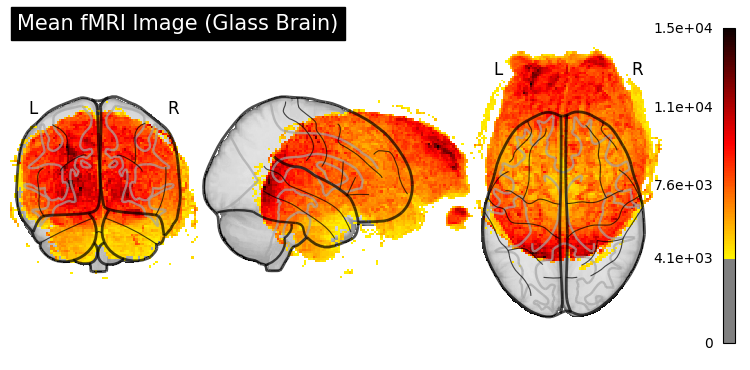

In [34]:
from nilearn import plotting, datasets
from nilearn.image import mean_img, resample_to_img
import matplotlib.pyplot as plt

# Assuming 'img' is your loaded fMRI image from the previous step

# Extract the mean image across the time dimension for visualization
# This converts the 4D fMRI data into a 3D image
mean_fmri_img = mean_img(img)
template = datasets.load_mni152_template()

# Plotting the mean fMRI image in "glass brain" view
plotting.plot_glass_brain(mean_fmri_img, bg_img=template, display_mode='ortho', title='Mean fMRI Image (Glass Brain)')
plt.show()

# Plotting slices of the mean fMRI image
# You can specify cuts (e.g., [-20, 0, 20] for sagittal, coronal, axial cuts)
#plotting.plot_epi(mean_fmri_img, title='Mean fMRI Image Slices', display_mode='ortho')
#plt.show()

# You can also save the plots
# plotting.plot_epi(mean_fmri_img, output_file='mean_fmri_slices.png')

In [35]:
mean_fmri_img.shape

(90, 104, 72)

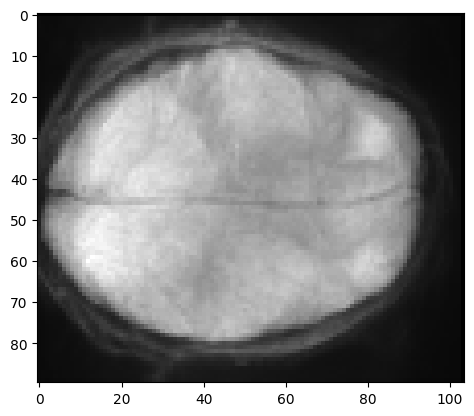

In [36]:
plt.imshow(mean_fmri_img.get_fdata().mean(axis=2), cmap='gray')

In [37]:
plt.imshow(mean_fmri_img.data[:, :, 10], cmap='gray')

AttributeError: 'Nifti1Image' object has no attribute 'data'

/tmp/ipykernel_107576/3667291790.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_fmri_img = image.mean_img(img)
/tmp/ipykernel_107576/3667291790.py:14: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_img = image.resample_to_img(mean_fmri_img, template, interpolation='continuous')
/tmp/ipykernel_107576/3667291790.py:14: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_img = image.resample_to_img(mean_fmri_img, template, interpolation='continuous')

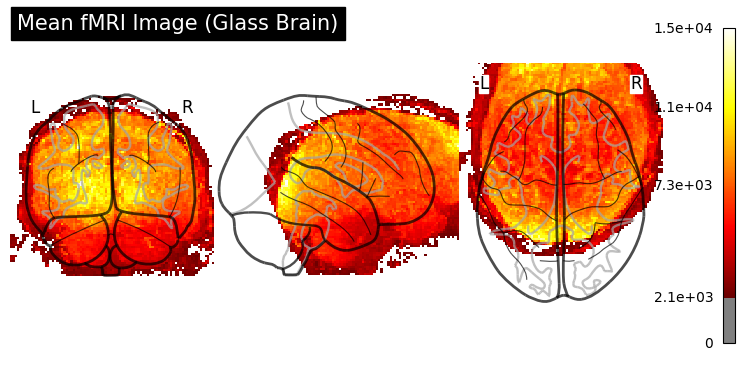

In [ ]:
from nilearn import plotting, datasets, image
import matplotlib.pyplot as plt
import nibabel as nib

# Load the image
# Replace this with your actual file if you're not assigning `img` earlier
# Compute the mean image
mean_fmri_img = image.mean_img(img)

# Load MNI template for alignment
template = datasets.load_mni152_template(resolution=2)

# Resample mean image to MNI template
resampled_img = image.resample_to_img(mean_fmri_img, template, interpolation='continuous')

# Ensure background is masked properly
masked_img = image.math_img("img * (img > 1e-6)", img=resampled_img)

# Plot using glass brain
plotting.plot_glass_brain(masked_img, display_mode='ortho',
                          colorbar=True, cmap='hot',
                          title="Mean fMRI Image (Glass Brain)",
                          plot_abs=False)

plt.show()


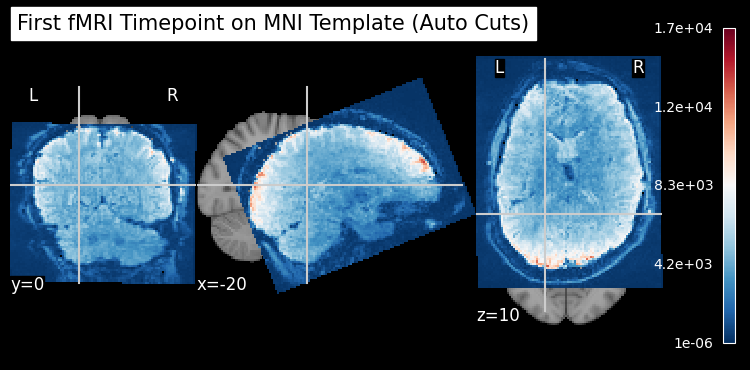

In [ ]:
# Let's say you have a 3D statistical map (e.g., 'stat_map.nii.gz')
# For demonstration, we'll just take the first time point of our fMRI data
first_timepoint_img = nib.Nifti1Image(data[..., 0], affine)

# You can also load an anatomical image (e.g., T1w) for background
# For this example, let's use a dataset from Nilearn for a background image
from nilearn import datasets
anat_img = datasets.load_mni152_template(resolution=2) # Load a standard anatomical template

manual_cut_coords = (-20, 0, 10)
# Plotting the first timepoint on an anatomical background
plotting.plot_stat_map(
    first_timepoint_img,
    bg_img=anat_img,
    display_mode='ortho',
    title='First fMRI Timepoint on MNI Template (Auto Cuts)',
    cut_coords=manual_cut_coords # This will automatically select 5 cuts for each plane (sagittal, coronal, axial)
)
plt.show()

In [ ]:
from nilearn import plotting
from nilearn.image import index_img # Import index_img

# Assuming 'img' is your loaded 4D fMRI image (nibabel object)
# And 'anat_img' is your background image (e.g., MNI template)

# Option A: Extract the first time point (index 0)
first_timepoint_img = index_img(img, 0) 

# Option B: Extract a specific time point (e.g., time point 10)
# specific_timepoint_img = index_img(img, 10)

# Now, plot the extracted 3D image
view = plotting.view_img(first_timepoint_img, bg_img=anat_img, title='Interactive Viewer - First Timepoint')
view.open_in_browser() 

/home/dani2442/Projects/neuroscience/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
2025/07/21 23:09:43.460166 cmd_run.go:1353: WARNING: cannot start document portal: dial unix /run/user/1000/bus: connect: no such file or directory
touch: cannot touch '/home/dani2442/snap/firefox/common/.cache/desktop-runtime-date': No such file or directory


RuntimeError: Failed to open nilearn plot or report in a web browser.

[114947, Main Thread] WARNING: Settings portal not found: Could not connect: No such file or directory: 'glib warning', file /build/firefox/parts/firefox/build/toolkit/xre/nsSigHandlers.cpp:201

(firefox_firefox:114947): Gdk-WARNING **: 23:09:45.697: Settings portal not found: Could not connect: No such file or directory
[Parent 114947, Main Thread] WARNING: Failed to mkdir /home/dani2442/snap/firefox/6495/.config/ibus/bus: Not a directory: 'glib warning', file /build/firefox/parts/firefox/build/toolkit/xre/nsSigHandlers.cpp:201

(firefox_firefox:114947): IBUS-WARNING **: 23:09:46.057: Failed to mkdir /home/dani2442/snap/firefox/6495/.config/ibus/bus: Not a directory
[Parent 114947, Main Thread] WARNING: Failed to create DBus proxy for org.a11y.Bus: Could not connect: No such file or directory
: 'glib warning', file /build/firefox/parts/firefox/build/toolkit/xre/nsSigHandlers.cpp:201

** (firefox_firefox:114947): WARNING **: 23:09:47.455: Failed to create DBus proxy for org.a11y.Bus: C